In [1]:
library(Seurat)
library(patchwork)
library(tidyverse) 

library(SingleR)
library(celldex)
library(SingleCellExperiment)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


In [2]:
data_int <- "../../results/sc_rna/03_annot/intermediate"

# Define directories
dir_fig <- "../../results/sc_rna/04_GSEA/figures"
dir_int <- "../../results/sc_rna/04_GSEA/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

In [3]:
merged_filt <- readRDS(file.path(data_int, "merged_filt.rds"))

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


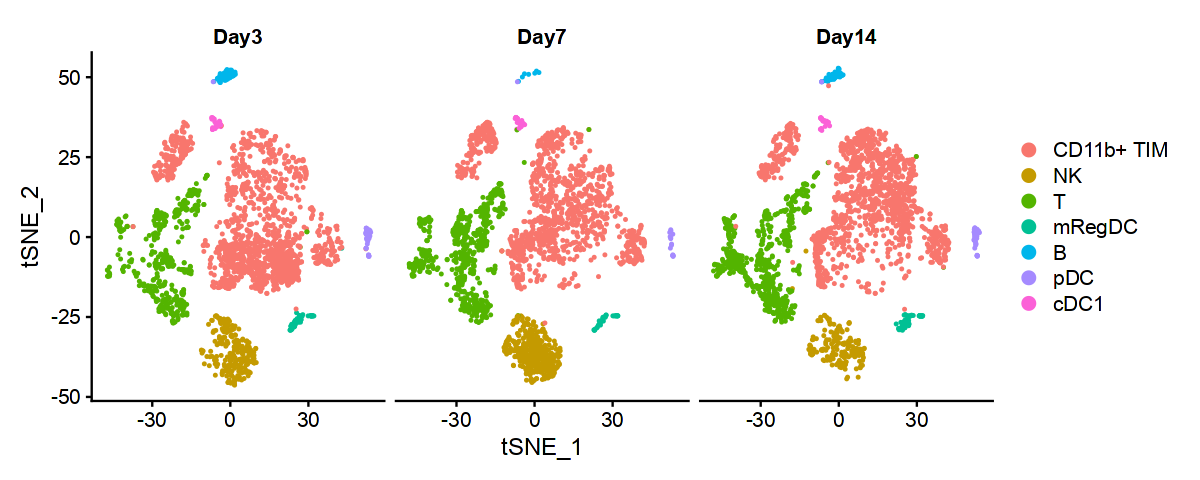

In [4]:
options(repr.plot.width = 10, repr.plot.height = 4)
DimPlot(merged_filt, reduction = "tsne", split.by='day')

In [5]:
levels(merged_filt)

[1] "CD11b+ TIM" "NK"         "T"          "mRegDC"     "B"         
[6] "pDC"        "cDC1"

In [6]:
TIM <- subset(merged_filt, idents = c("CD11b+ TIM"))

In [7]:
TIM

An object of class Seurat 
16245 features across 4582 samples within 1 assay 
Active assay: RNA (16245 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

# GSEA analysis


In [8]:
DefaultAssay(TIM)
table(TIM$orig.ident)

[1] "RNA"


day03 day07 day14 
 1669  1281  1632 

In [9]:
get_GSEA_ranked_list <- function(seuratobj, cell_type, set1, set2, output_file) {
  # Add meta data
  seuratobj[["group"]] <- recode(seuratobj@meta.data$orig.ident, "day03" = "Day3", "day07" = "Day7", "day14" = "Day14")
  
  # Subset the specified cell type
  cell_subset <- subset(seuratobj, idents = cell_type)
  cell_subset <- SetIdent(cell_subset, value = "group")  # Set the group information (Day3, Day7, Day14) as the active identity

  # DEG analysis
  ranked_list <- FindMarkers(cell_subset, ident.1 = set1, ident.2 = set2, min.pct = 0.1, logfc.threshold = 0)

  # Sort by log fold change (descending order)
  ranked_list <- ranked_list[order(ranked_list$avg_log2FC, decreasing = TRUE),]
  
  # Add gene names and select relevant columns
  ranked_list$Gene.name <- rownames(ranked_list)
  ranked_list <- ranked_list[,c("Gene.name", "avg_log2FC")]
  rownames(ranked_list) <- NULL

  # Save as `.rnk` file for GSEA input
  write.table(ranked_list, file = output_file, sep = "\t", row.names = F, quote = F)
}

In [10]:
prepare_ranked_list <- function(ranked_list) { 
  # if duplicate gene names present, average the values
  if( sum(duplicated(ranked_list$Gene.name)) > 0) {
    ranked_list <- aggregate(.~Gene.name, FUN = mean, data = ranked_list)
    ranked_list <- ranked_list[order(ranked_list$avg_log2FC, decreasing = T),]
  }
  # omit rows with NA values
  ranked_list <- na.omit(ranked_list)
  # turn the dataframe into a named vector
  ranked_list <- tibble::deframe(ranked_list)
  ranked_list
}

In [11]:
library(fgsea)
hallmark_pathway <- gmtPathways("/home/hiroki578/Usersdata2/Kasai/Doctor/b16_act_analysis/data/pathway_files/mh.all.v2025.1.Mm.symbols.gmt")

In [12]:
comparisons <- list(
  c("Day3", "Day7"),
  c("Day3", "Day14")
)

In [13]:
out_dir_rnk <- file.path(dir_fig, "rnk_TIM")
dir.create(out_dir_rnk, recursive=TRUE, showWarnings=FALSE)

target_label <- "CD11b+ TIM"

for (cmp in comparisons) {
  set1 <- cmp[1]; set2 <- cmp[2]
  fname <- sprintf("%s_%s_vs_%s_ranked.rnk", target_label, set1, set2)
  
  get_GSEA_ranked_list(
    seuratobj   = TIM, 
    cell_type   = levels(TIM), 
    set1        = set1,
    set2        = set2,
    output_file = file.path(out_dir_rnk, fname)
  )
}

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [14]:
fgsea_results_list <- list()

for (cmp in comparisons) {
  set1 <- cmp[1]; set2 <- cmp[2]
  key <- sprintf("%s_%s_vs_%s", target_label, set1, set2)
  rnk_file <- file.path(out_dir_rnk, paste0(key, "_ranked.rnk"))
  
  if (file.exists(rnk_file)) {
    rl <- read.table(rnk_file, header = TRUE)
    
    colnames(rl) <- c("Gene.name", "avg_logFC") 
    rank_vector <- prepare_ranked_list(rl)
    
    fgsea_res <- fgsea(pathways = hallmark_pathway, 
                       stats = rank_vector,
                       minSize = 15,
                       maxSize = 500)
    
    fgsea_results_list[[key]] <- fgsea_res
    message("Completed: ", key)
  }
}

Completed: CD11b+ TIM_Day3_vs_Day7

Completed: CD11b+ TIM_Day3_vs_Day14



In [15]:
plot_enrichment <- function (geneset, pathway, ranked_list) {
  plotEnrichment(geneset[[pathway]], ranked_list)+labs (title = pathway)
}

waterfall_plot <- function (fgsea_results, graph_title) {
  fgsea_results %>% 
    mutate(short_name = str_split_fixed(pathway, "_",2)[,2])%>%
    ggplot( aes(reorder(short_name,NES), NES)) +
      geom_bar(stat= "identity", aes(fill = padj<0.05))+
      coord_flip()+
      labs(x = "Hallmark Pathway", y = "Normalized Enrichment Score", title = graph_title)+
      theme(axis.text.y = element_text(size = 12), 
            plot.title = element_text(hjust = 1))
}

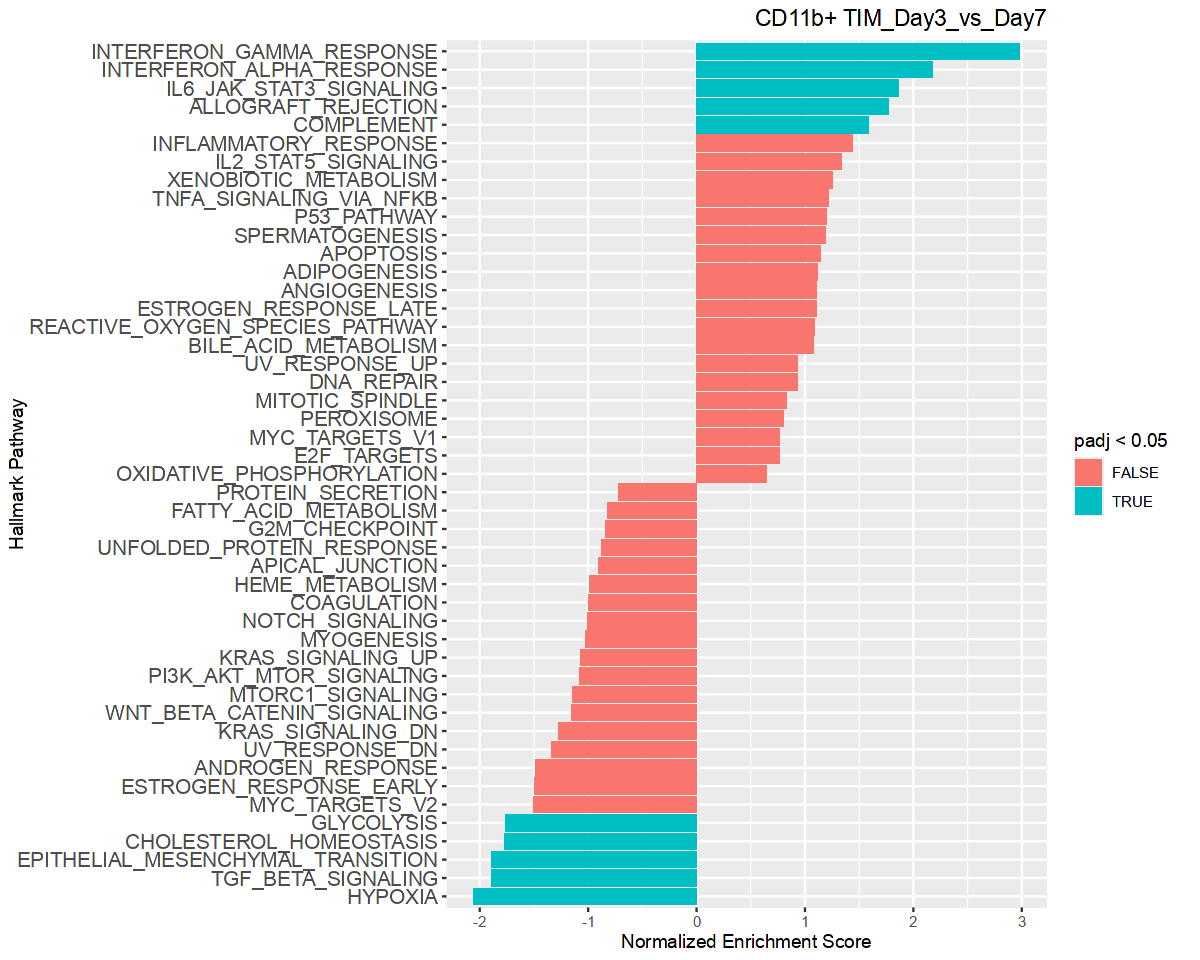

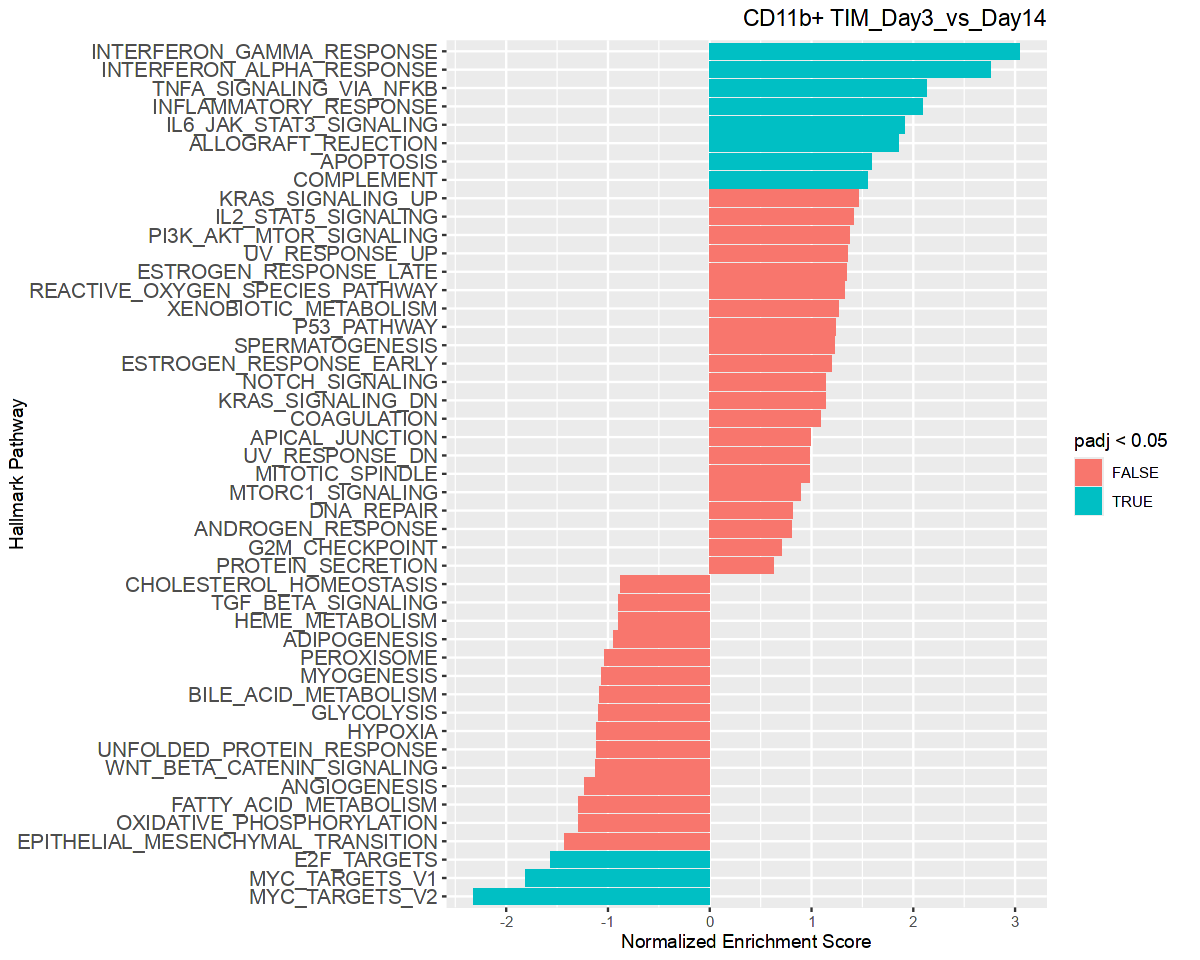

In [16]:
options(repr.plot.width = 10, repr.plot.height = 8)

out_dir_waterfall <- file.path(dir_fig, "waterfall_TIM")
dir.create(out_dir_waterfall, showWarnings = FALSE, recursive = TRUE)

for (key in names(fgsea_results_list)) {
  if (nrow(fgsea_results_list[[key]]) == 0) next
  
  # plot
  p <- waterfall_plot(fgsea_results_list[[key]], graph_title = key)
  
  # save
  ggsave(file.path(out_dir_waterfall, paste0(key, ".jpeg")), plot = p, device = "jpeg", width = 8, height = 8, dpi = 300)
  ggsave(file.path(out_dir_waterfall, paste0(key, ".pdf")),  plot = p, device = "pdf",  width = 8, height = 8)
  
  print(p)
}